<a href="https://colab.research.google.com/github/nagi0218/nagi0218/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 資料前處理完成 ===

🔥 開始訓練模型 A（64-32-16）


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4735 - loss: 1.0121 - val_accuracy: 0.8294 - val_loss: 0.5667
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8279 - loss: 0.5052 - val_accuracy: 0.8735 - val_loss: 0.3347
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8904 - loss: 0.3136 - val_accuracy: 0.9059 - val_loss: 0.2650
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8959 - loss: 0.2968 - val_accuracy: 0.9088 - val_loss: 0.2384
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8995 - loss: 0.2650 - val_accuracy: 0.9088 - val_loss: 0.2255
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9013 - loss: 0.2462 - val_accuracy: 0.9176 - val_loss: 0.2057
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9072 - loss: 0.2217 - val_accuracy: 0.9265 - val_loss: 0.2034
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9221 - loss: 0.1969 - val_accuracy: 0.9176 - val_lo

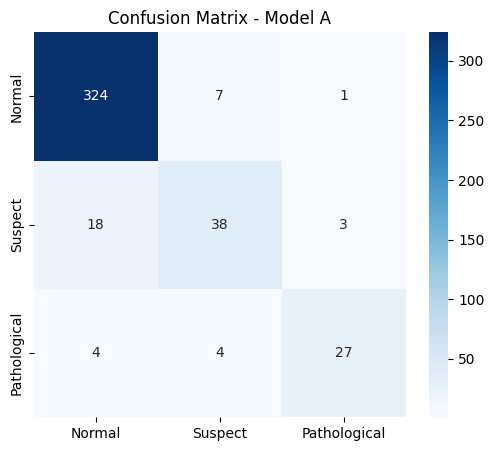

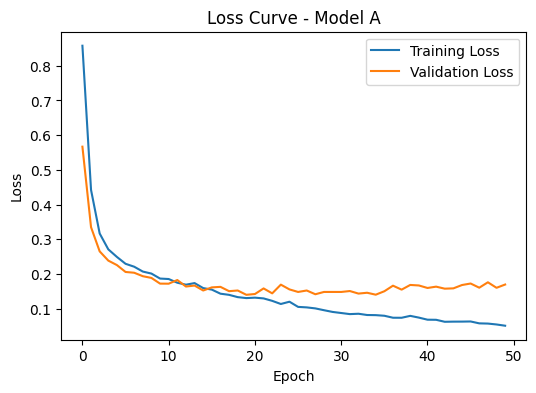

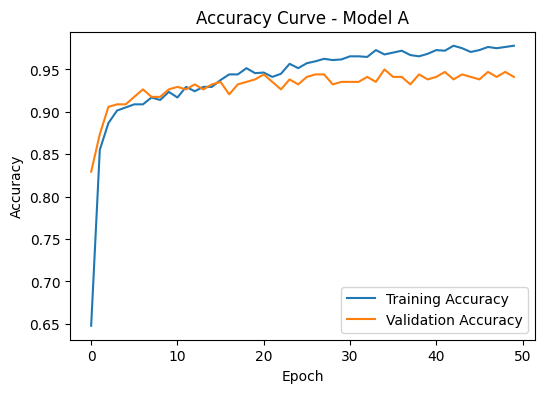


🎉 模型 A 訓練與評估全部完成 🎉


In [2]:
# ============================================================
# 第一部分：資料前處理
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("sample_data/fetal_health.csv")

X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== 資料前處理完成 ===")


# ============================================================
# 第二部分：建立 Keras 模型（只留模型 A）
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train - 1)
y_test_cat = to_categorical(y_test - 1)

# 模型 A：64 → 32 → 16 → 3
def create_model_A():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(21,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# ============================================================
# 第三部分：訓練模型 A（含 Loss / Accuracy 圖）
# ============================================================

print("\n🔥 開始訓練模型 A（64-32-16）")
model_A = create_model_A()

history_A = model_A.fit(
    X_train_scaled, y_train_cat,
    epochs=50, batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("=== 模型 A 訓練完成 ===")

from sklearn.metrics import confusion_matrix, classification_report

# Model A 預測
y_pred_prob = model_A.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

test_loss_A, test_acc_A = model_A.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\n📌 Model A Test Accuracy：{test_acc_A:.4f}")

print("\n📌 Model A Classification Report：")
print(classification_report(
    y_true, y_pred,
    target_names=["Normal", "Suspect", "Pathological"]
))

# Model A 混淆矩陣
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Suspect", "Pathological"],
            yticklabels=["Normal", "Suspect", "Pathological"])
plt.title("Confusion Matrix - Model A")
plt.show()

# Model A Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history_A.history['loss'], label='Training Loss')
plt.plot(history_A.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve - Model A")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Model A Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(history_A.history['accuracy'], label='Training Accuracy')
plt.plot(history_A.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve - Model A")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("\n🎉 模型 A 訓練與評估全部完成 🎉")
